In [1]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu117 --no-cache-dir --force-reinstall -q
# !pip install numpy==1.26.3 --no-deps

In [2]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
from diffusers import AutoencoderKL


2025-03-27 09:31:48.283277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-27 09:31:48.297093: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-27 09:31:48.301330: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-27 09:31:48.311928: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-27 09:31:49.121381: W tensorflow/compiler/tf2

In [3]:
from torch.distributions import Uniform

class UniformVAE(AutoencoderKL):
    def reparameterize(self, mu, logvar):
        # Uniform distribution sampling
        std = torch.exp(0.5 * logvar)
        uniform_dist = Uniform(-1.0, 1.0)  # Uniform distribution in [-1, 1]
        eps = uniform_dist.sample(mu.shape).to(mu.device)  # Sample noise
        z = mu + eps * std  # Scale and shift
        return z

In [4]:
# Setup device and load pretrained VAE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

vae = UniformVAE.from_pretrained("KBlueLeaf/EQ-SDXL-VAE").to(device)

# Ensure all parameters are trainable
for param in vae.parameters():
    param.requires_grad = True

# Set the model to train mode
vae.train()
print("VAE is in train mode and ready for fine-tuning.")

Using device: cuda
VAE is in train mode and ready for fine-tuning.


In [5]:
# Load the dataset from Hugging Face Hub
dataset = load_dataset("Zaurall/floor_coverings_1", split="train")

In [6]:
# Filter dataset: keep only rows where the 'name1' field's id part is less than 60,000.
def filter_func(example):
    # Split the name (e.g. "00091_0") and take the first part as id
    id_str = example["name1"].split("_")[0]
    return int(id_str) < 60000

filtered_dataset = dataset.filter(filter_func)

In [7]:
# Split into train and test sets (here using a 90/10 split)
split_dataset = filtered_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

In [8]:
# Define a transform: adjust size and normalize as needed by your model.
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Adjust dimensions if necessary
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Change normalization values depending on your data
])

# Create a PyTorch Dataset that reads images from the HF dataset.
# Here we assume that "image2" is the target image (the generated parquet pattern).
class FloorCoveringsDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image = sample["image2"]  # Use image2 as the reconstruction target.
        if self.transform:
            image = self.transform(image)
        return image

train_data = FloorCoveringsDataset(train_dataset, transform)
test_data = FloorCoveringsDataset(test_dataset, transform)


In [9]:
# Prepare DataLoaders
train_loader = DataLoader(train_data, batch_size=4, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=4, pin_memory=True)

In [10]:
# Define optimizer and loss function.
optimizer = optim.AdamW(vae.parameters(), lr=1e-4)
criterion = nn.MSELoss()  # Using mean squared error as the reconstruction loss

# Training loop
num_epochs = 2

In [11]:
from tqdm import tqdm

# Initialize variables for tracking the best loss
best_loss = float("inf")
best_model_weights = None

for epoch in range(num_epochs):
    running_loss = 0.0
    
    # Wrap the train_loader with tqdm for a progress bar
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    
    for batch in train_loader_tqdm:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Encode the input image into the latent space
        latent_dist = vae.encode(batch).latent_dist
        latents = latent_dist.sample()
        
        # Decode the latent representation back into image space
        recon = vae.decode(latents).sample
        
        # Compute the reconstruction loss
        loss = criterion(recon, batch)
        loss.backward()
        
		# Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Update the running loss
        running_loss += loss.item()
        
        # Update the progress bar description with the current batch loss
        train_loader_tqdm.set_postfix(loss=loss.item())
    
    # Calculate the average loss for the epoch
    avg_loss = running_loss / len(train_loader)
    
    # Print the average loss for the epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/2, Loss: 0.0020


Epoch 2/2, Loss: 0.0013


In [12]:
vae.save_pretrained(f"../models/vae/finetuned_vae_another_dim_2")

Average Test Loss: 0.0023


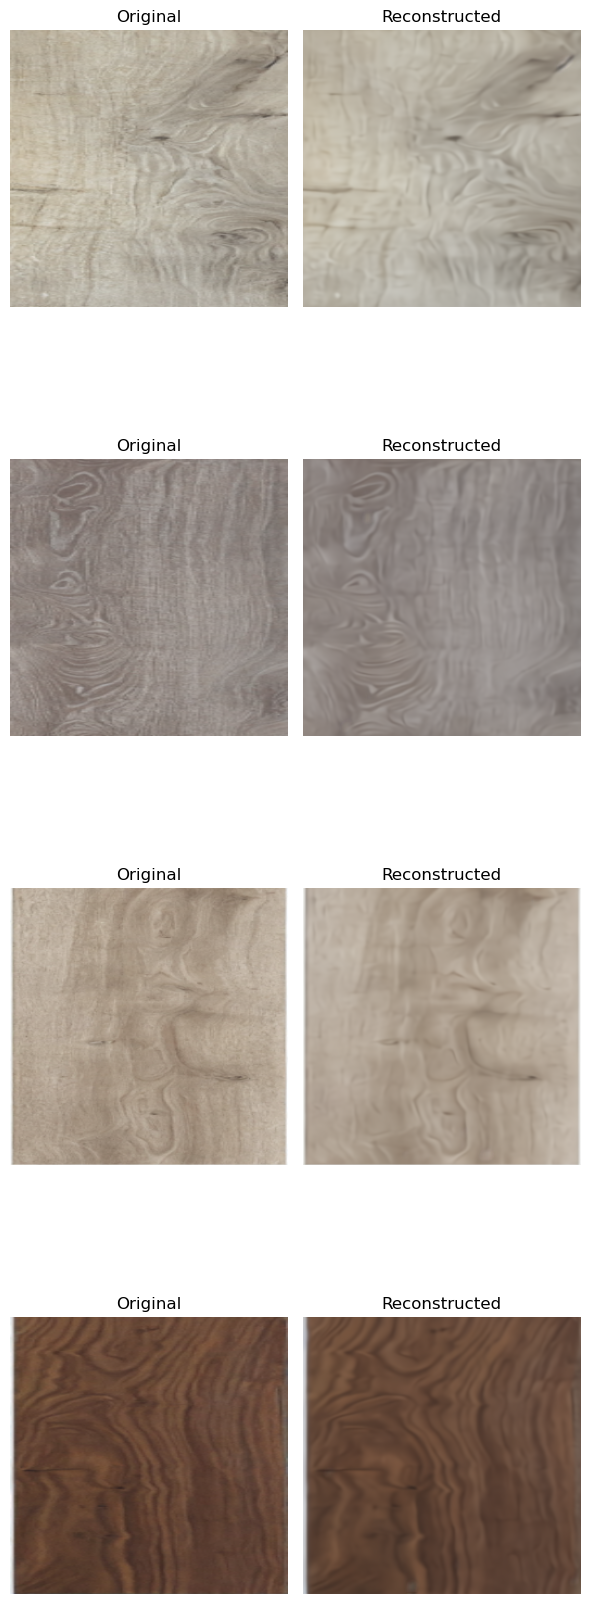

In [13]:
import matplotlib.pyplot as plt

# Switch the model to evaluation mode.
vae.eval()

test_loader = DataLoader(test_data, batch_size=4)

# Compute average reconstruction loss on the test dataset.
test_loss = 0.0
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        # Encode the batch into latent space.
        latent_dist = vae.encode(batch).latent_dist
        latents = latent_dist.sample()
        # Decode the latent representation back to image space.
        recon = vae.decode(latents).sample
        
        # Compute the reconstruction loss (MSE).
        loss = criterion(recon, batch)
        test_loss += loss.item() * batch.size(0)

avg_test_loss = test_loss / len(test_data)
print(f"Average Test Loss: {avg_test_loss:.4f}")

# Optional: Visualize some examples.
with torch.no_grad():
    # Get one batch of test images.
    sample_batch = next(iter(test_loader))
    sample_batch = sample_batch.to(device)
    latent_dist = vae.encode(sample_batch).latent_dist
    latents = latent_dist.sample()
    recons = vae.decode(latents).sample

# Move images to CPU for visualization.
sample_batch = sample_batch.cpu().numpy()
recons = recons.cpu().numpy()

# Create a figure to compare original and reconstructed images.
fig, axes = plt.subplots(4, 2, figsize=(6, 18))
for i in range(4):
    # Display original image (undo normalization assuming mean=0.5, std=0.5).
    axes[i, 0].imshow(sample_batch[i].transpose(1, 2, 0) * 0.5 + 0.5)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    # Display reconstructed image.
    axes[i, 1].imshow(recons[i].transpose(1, 2, 0) * 0.5 + 0.5)
    axes[i, 1].set_title("Reconstructed")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [14]:
num_epochs = 100

In [ ]:
from tqdm import tqdm
import os

# Initialize variables for tracking the best loss
best_loss = float("inf")
best_model_weights = None
early_stopping_counter = 0
patience = 10  # Number of epochs to wait before stopping
save_dir = "../models/vae/"  # Directory to save models

for epoch in range(num_epochs):
    vae.train()
    running_loss = 0.0
    
    # Wrap the train_loader with tqdm for a progress bar
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    
    for batch in train_loader_tqdm:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Encode the input image into the latent space
        latent_dist = vae.encode(batch).latent_dist
        latents = latent_dist.sample()
        
        # Decode the latent representation back into image space
        recon = vae.decode(latents).sample
        
        # Compute the reconstruction loss
        loss = criterion(recon, batch)
        loss.backward()
        
		# Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Update the running loss
        running_loss += loss.item()
        
        # Update the progress bar description with the current batch loss
        train_loader_tqdm.set_postfix(loss=loss.item())
    
    # Calculate the average loss for the epoch
    avg_loss = running_loss / len(train_loader)
    
    # Print the average loss for the epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    # Validation phase
    vae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            # Encode the batch into latent space.
            latent_dist = vae.encode(batch).latent_dist
            latents = latent_dist.sample()
            # Decode the latent representation back to image space.
            recon = vae.decode(latents).sample
            
            # Compute the reconstruction loss (MSE).
            loss = criterion(recon, batch)
            val_loss += loss.item() * batch.size(0)

    avg_val_loss = val_loss / len(test_loader)

    if (epoch+1) % 10 == 0:
        vae.save_pretrained(f"{save_dir}/finetuned_vae_another_dim_{(epoch+1)}")
    
    # Early stopping and model checkpointing
    if avg_val_loss < best_loss:
        print(f"Validation loss improved from {best_loss:.4f} to {avg_val_loss:.4f}")
        best_loss = avg_val_loss
        best_model_weights = vae.state_dict().copy()
        early_stopping_counter = 0
        
    else:
        early_stopping_counter += 1
        print(f"Early stopping counter: {early_stopping_counter}/{patience}")
        if early_stopping_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break


Epoch 1/100, Loss: 0.0012
Validation loss improved from inf to 0.0052


Epoch 2/100, Loss: 0.0012
Early stopping counter: 1/10


Epoch 3/100, Loss: 0.0012
Early stopping counter: 2/10


Epoch 4/100, Loss: 0.0012
Early stopping counter: 3/10


Epoch 5/100, Loss: 0.0012
Validation loss improved from 0.0052 to 0.0050


...

Epoch 8/100, Loss: 0.0017
Early stopping counter: 2/10


Epoch 9/100, Loss: 0.0010
Validation loss improved from 0.0049 to 0.0047


Epoch 10/100, Loss: 0.0010
Validation loss improved from 0.0047 to 0.0047


Epoch 11/100, Loss: 0.0010
Validation loss improved from 0.0047 to 0.0047


Epoch 12/100:  60%|█████▉    | 312/522 [02:40<01:51,  1.89it/s, loss=0.000563]

In [20]:
# Save the best model
torch.save({
    'epoch': epoch,
    'model_state_dict': vae.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': best_loss,
}, os.path.join(save_dir, f"best_model_another_dim_epoch_{epoch+1}.pth"))
print(f"Saved best model at epoch {epoch+1}")

Saved best model at epoch 100


In [18]:
if best_model_weights is not None:
    vae.load_state_dict(best_model_weights)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Average Test Loss: 0.0004


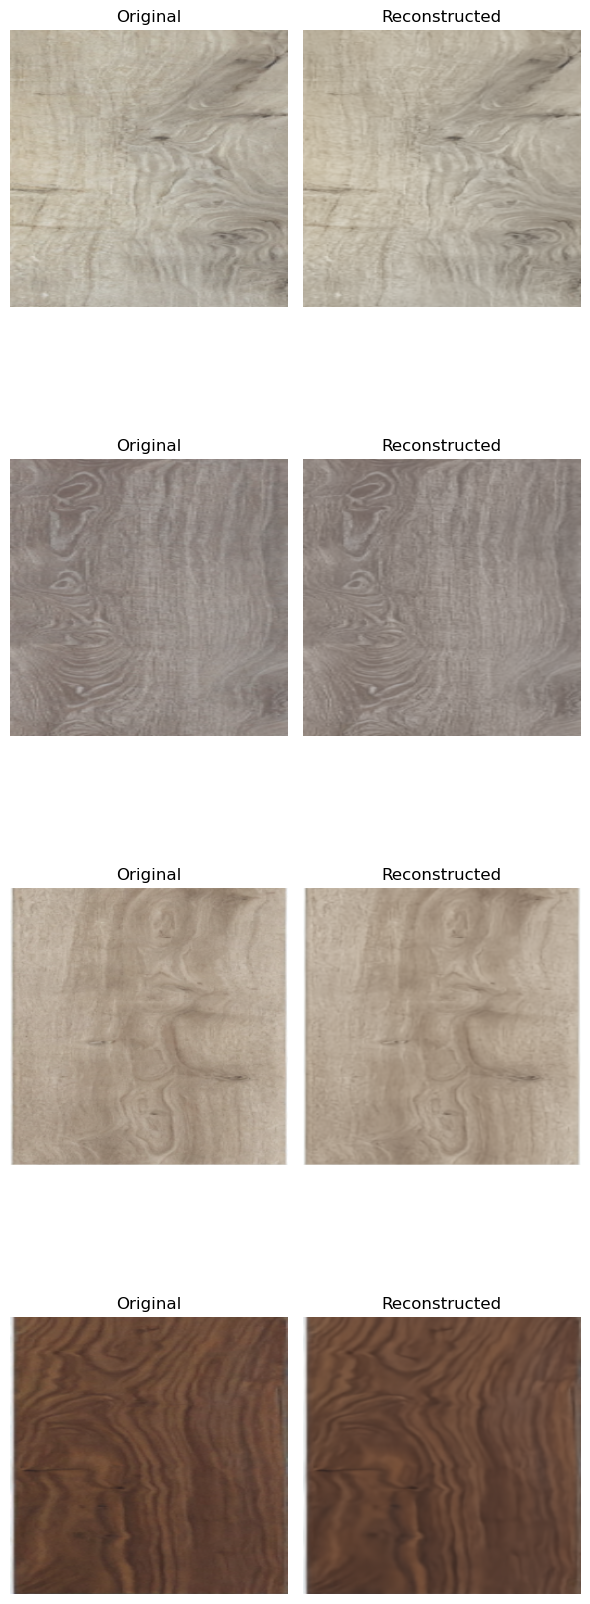

In [19]:
# Switch the model to evaluation mode.
vae.eval()

test_loader = DataLoader(test_data, batch_size=4)

# Compute average reconstruction loss on the test dataset.
test_loss = 0.0
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        # Encode the batch into latent space.
        latent_dist = vae.encode(batch).latent_dist
        latents = latent_dist.sample()
        # Decode the latent representation back to image space.
        recon = vae.decode(latents).sample
        
        # Compute the reconstruction loss (MSE).
        loss = criterion(recon, batch)
        test_loss += loss.item() * batch.size(0)

avg_test_loss = test_loss / len(test_data)
print(f"Average Test Loss: {avg_test_loss:.4f}")

# Optional: Visualize some examples.
with torch.no_grad():
    # Get one batch of test images.
    sample_batch = next(iter(test_loader))
    sample_batch = sample_batch.to(device)
    latent_dist = vae.encode(sample_batch).latent_dist
    latents = latent_dist.sample()
    recons = vae.decode(latents).sample

# Move images to CPU for visualization.
sample_batch = sample_batch.cpu().numpy()
recons = recons.cpu().numpy()

# Create a figure to compare original and reconstructed images.
fig, axes = plt.subplots(4, 2, figsize=(6, 18))
for i in range(4):
    # Display original image (undo normalization assuming mean=0.5, std=0.5).
    axes[i, 0].imshow(sample_batch[i].transpose(1, 2, 0) * 0.5 + 0.5)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    # Display reconstructed image.
    axes[i, 1].imshow(recons[i].transpose(1, 2, 0) * 0.5 + 0.5)
    axes[i, 1].set_title("Reconstructed")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Saving best model

torch.save({
    'epoch': num_epochs,
    'model_state_dict': vae.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': best_loss,
}, "final_model.pth")

As we can see, our Custom VAE just copies the input picture, so we will try changing loss to be perceptual. This experiment will be in `train_vae_perceptual_loss.ipynb`